<a href="https://colab.research.google.com/github/G4RG111/G4RG111/blob/main/Heart_Disease_Bias_Mitigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# preprocessing
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
#import pandas_profiling as pp

# models
from sklearn.linear_model import LinearRegression, SGDRegressor, RidgeCV
from sklearn.svm import SVR, LinearSVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.ensemble import BaggingRegressor, AdaBoostRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
import sklearn.model_selection
from sklearn.model_selection import cross_val_predict as cvp
from sklearn import metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA as PCA
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

# model tuning
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe, space_eval

import warnings
warnings.filterwarnings("ignore")

**Creating a dataframe**



In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("/content/heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


**Gender Bar Graph**

In [ ]:
df.shape
total_nan_count = df.isnull().sum().sum()
print(total_nan_count)

0


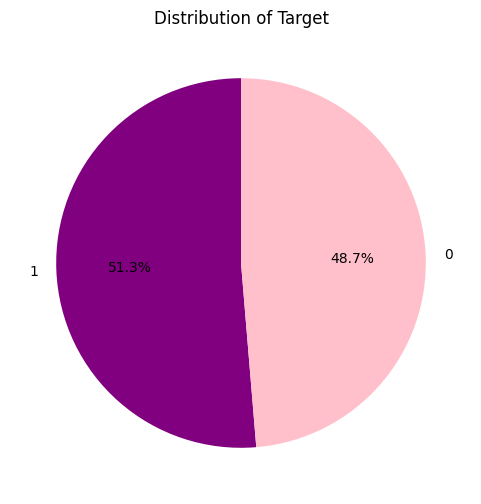

In [ ]:
target_counts = df['target'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=90, colors=['purple', 'pink'])
plt.title('Distribution of Target')
plt.show()

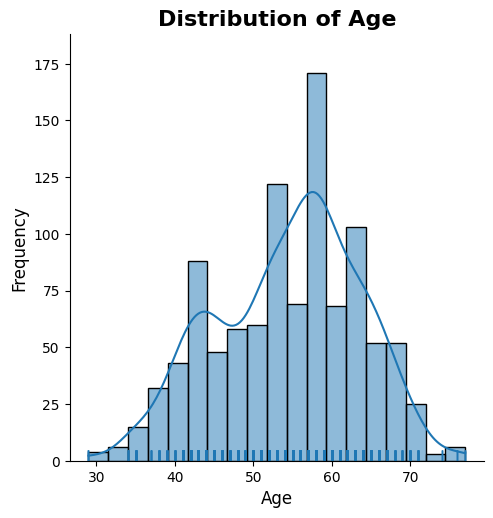

In [ ]:
sns.displot(df['age'], kde=True, rug=True)
plt.title('Distribution of Age',fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

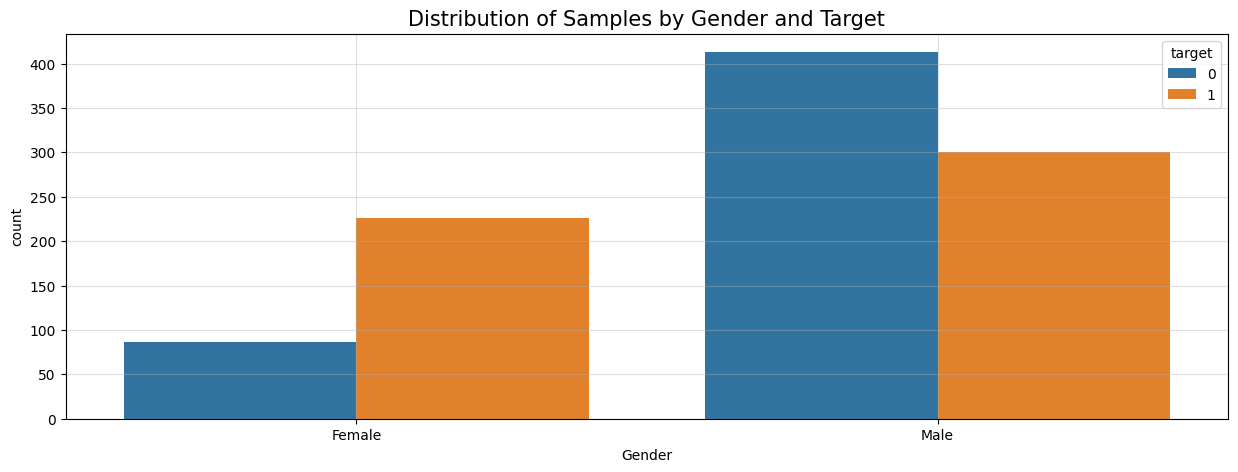

In [ ]:
from scipy.stats import chi2_contingency

# visualization (bar chart)
plt.figure(figsize=(15,5))
sns.countplot(data=df, x=df['sex'], hue=df['target'])
plt.xlabel('Gender')
plt.xticks(ticks=[0, 1], labels=['Female','Male'])
plt.title('Distribution of Samples by Gender and Target', fontsize=15)
plt.grid(alpha=0.4)
plt.show()


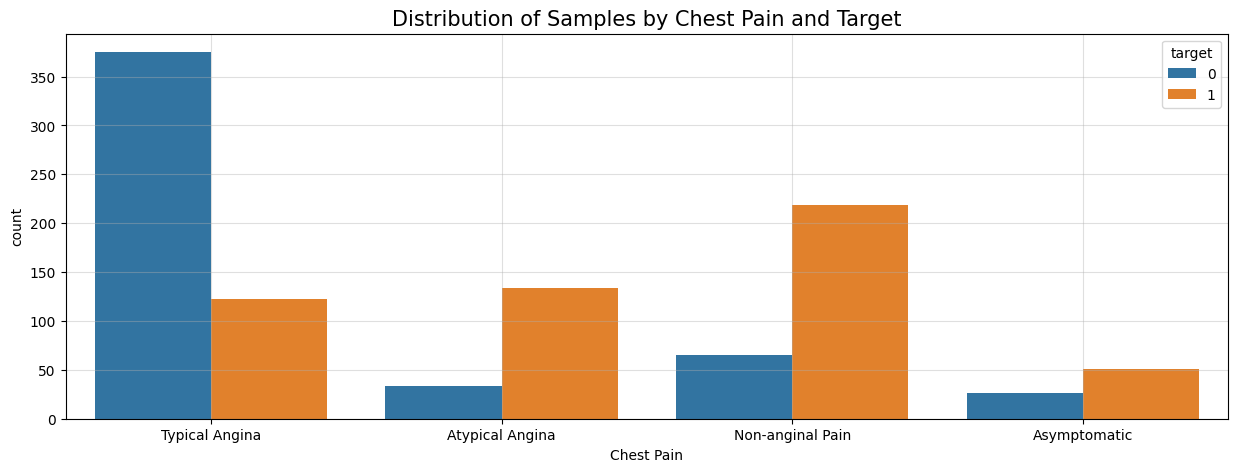

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(data=df, x=df['cp'], hue=df['target'])
plt.xlabel('Chest Pain')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'])
plt.title('Distribution of Samples by Chest Pain and Target', fontsize=15)
plt.grid(alpha=0.4)
plt.show()

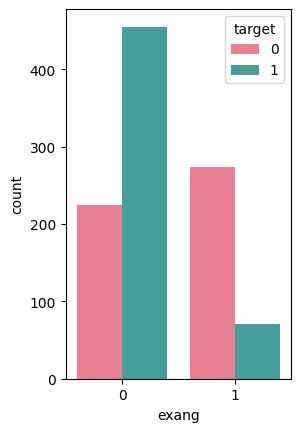

In [ ]:
plt.subplot(122)
sns.countplot(hue='target',x='exang',data=df,palette='husl')
plt.show()

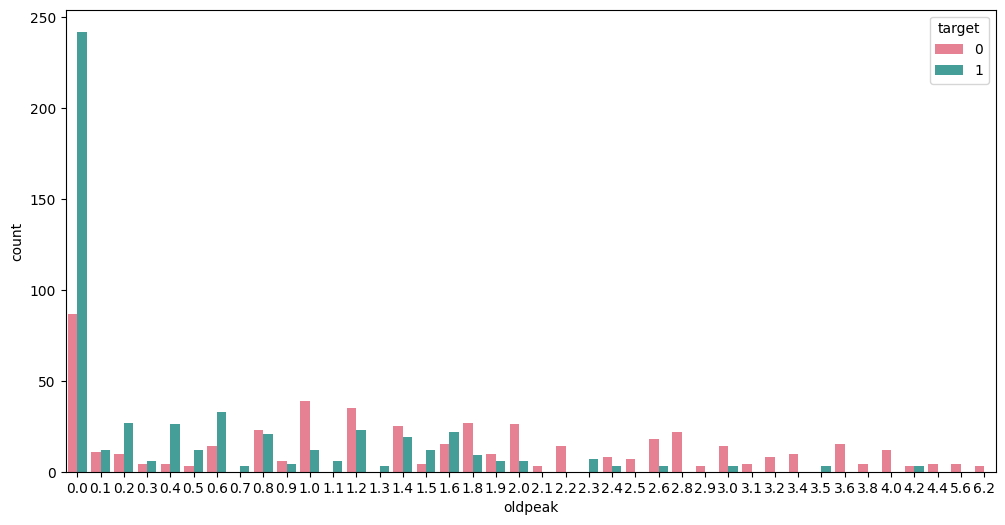

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the width and height of the plot
plt.figure(figsize=(12, 6))

# Plot the countplot
sns.countplot(hue='target', x='oldpeak', data=df, palette='husl')

# Show the plot
plt.show()

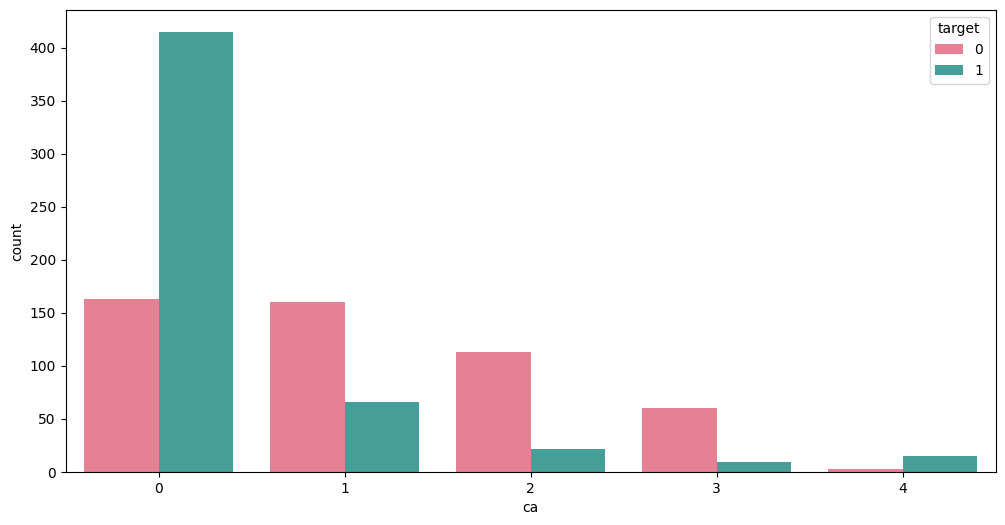

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the width and height of the plot
plt.figure(figsize=(12, 6))

# Plot the countplot
sns.countplot(hue='target', x='ca', data=df, palette='husl')

# Show the plot
plt.show()

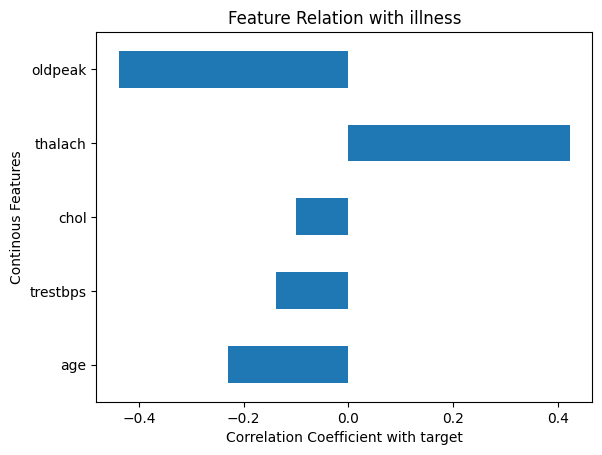

In [ ]:
df[['age', 'trestbps','chol','thalach','oldpeak','target']].corr()['target'][:-1].plot.barh()
plt.title("Feature Relation with illness")
plt.xlabel('Correlation Coefficient with target')
plt.ylabel('Continous Features')
plt.show()

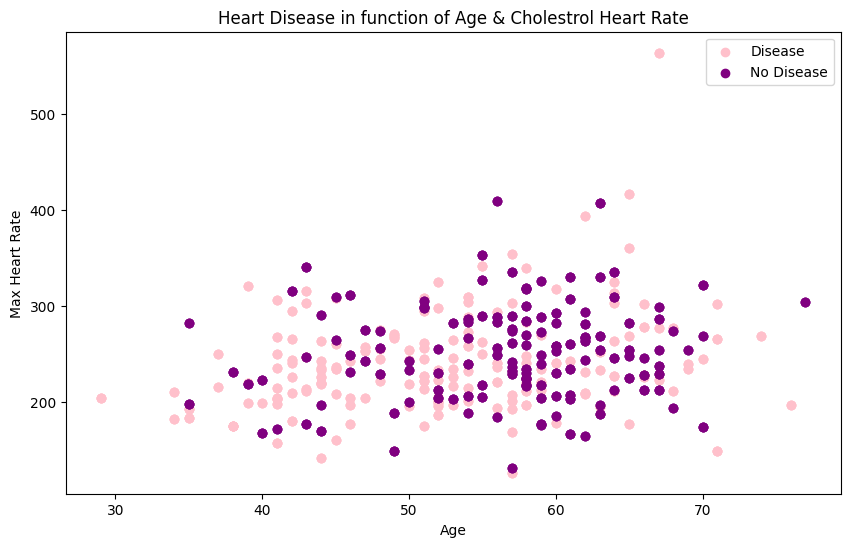

In [ ]:
plt.figure(figsize=(10,6))

# Scatter with positive examples
plt.scatter(df.age[df.target==1],
           df.chol[df.target==1],
           c="pink");

# Scatter with negative examples
plt.scatter(df.age[df.target==0],
           df.chol[df.target==0],
           c="purple");

# add some helpful title
plt.title("Heart Disease in function of Age & Cholestrol Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"]);

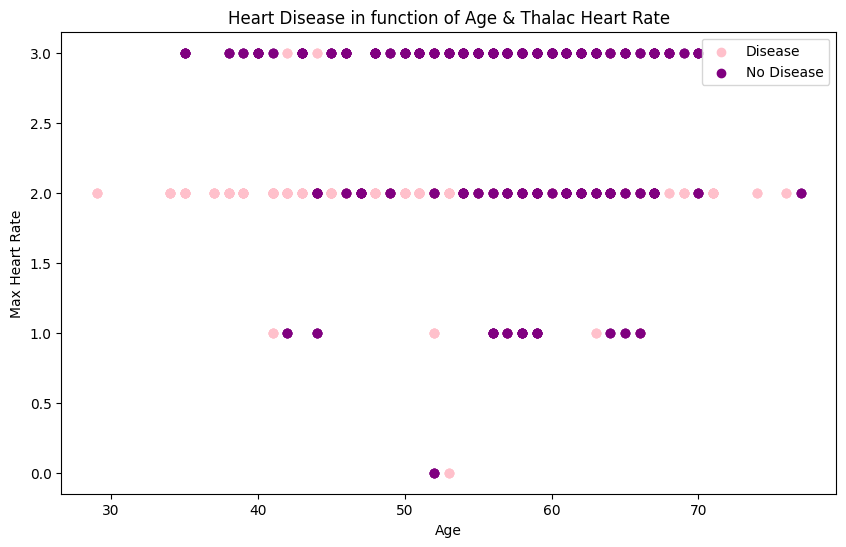

In [ ]:
plt.figure(figsize=(10,6))

# Scatter with positive examples
plt.scatter(df.age[df.target==1],
           df.thal[df.target==1],
           c="pink");

# Scatter with negative examples
plt.scatter(df.age[df.target==0],
           df.thal[df.target==0],
           c="purple");

# add some helpful title
plt.title("Heart Disease in function of Age & Thalac Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"]);

In [ ]:
df.corr()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
cp,-0.071966,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441
slope,-0.169105,0.131633,-0.120445,-0.014248,-0.061902,0.086086,0.395308,-0.267335,-0.575189,1.000000,-0.073440,-0.094090,0.345512


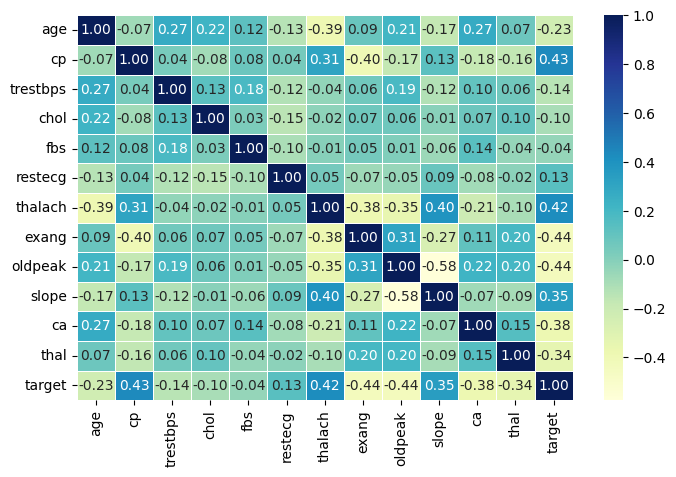

In [ ]:
# visualizing correlation in heatmap
corr_matrix = df.corr()
fig, ax =plt.subplots(figsize=(8,5))
ax = sns.heatmap(corr_matrix,
                annot=True,
                linewidths=0.5,
                fmt=".2f",
                cmap="YlGnBu");


Bias metrics for age:
Protected Attribute: age
Disparate Impact: nan
Statistical Parity Difference: nan
Equal Opportunity Difference: nan

Bias metrics for sex:
Protected Attribute: sex
Disparate Impact: 1.721559829059829
Statistical Parity Difference: 0.3036016111051174
Equal Opportunity Difference: 0.0

Bias metrics for cp:
Protected Attribute: cp
Disparate Impact: 0.3059251028559416
Statistical Parity Difference: -0.5569223725587056
Equal Opportunity Difference: 0.0

Bias metrics for trestbps:
Protected Attribute: trestbps
Disparate Impact: nan
Statistical Parity Difference: nan
Equal Opportunity Difference: nan

Bias metrics for chol:
Protected Attribute: chol
Disparate Impact: nan
Statistical Parity Difference: nan
Equal Opportunity Difference: nan

Bias metrics for fbs:
Protected Attribute: fbs
Disparate Impact: 1.1244185295257785
Statistical Parity Difference: 0.05773670324398872
Equal Opportunity Difference: 0.0

Bias metrics for restecg:
Protected Attribute: restecg
Disparate

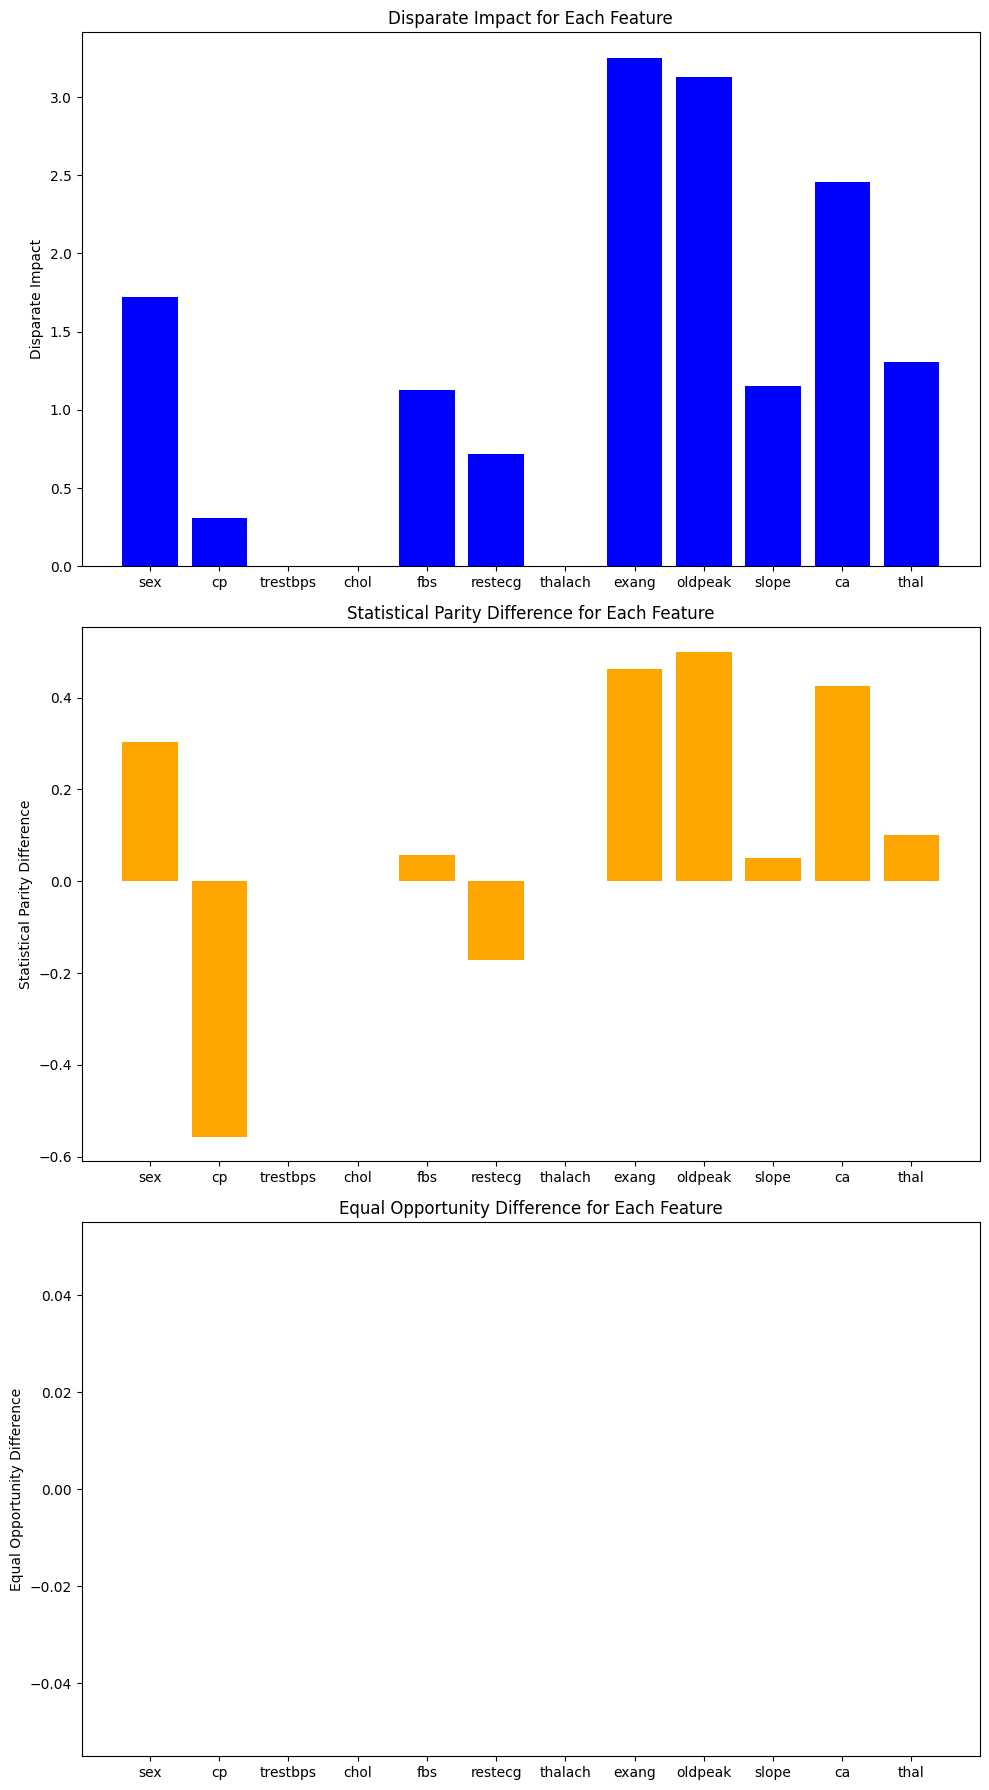

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from aif360.datasets import StandardDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric

def calculate_bias_metrics(df, target_column, feature_columns, protected_attribute):
    # Initialize a dictionary to store bias metrics
    bias_metrics = {}

    # Initialize lists to store fairness metrics for visualization
    disparate_impact_values = []
    statistical_parity_difference_values = []
    equal_opportunity_difference_values = []

    # Initialize a list to store protected attributes with disparate impact greater than one
    protected_attributes_with_disparate_impact = []

    # Detect bias for each feature
    for protected_attribute in feature_columns:
        # Create a BinaryLabelDataset
        dataset = StandardDataset(df, label_name=target_column, favorable_classes=[1],
                                  protected_attribute_names=[protected_attribute], privileged_classes=[[1]])

        # Calculate fairness metrics using BinaryLabelDatasetMetric
        metric = BinaryLabelDatasetMetric(dataset, unprivileged_groups=[{protected_attribute: 0}],
                                          privileged_groups=[{protected_attribute: 1}])

        # classified_metric = ClassificationMetric(dataset,
        #                                         dataset,
        #                                         unprivileged_groups=[{protected_attribute: 0}],
        #                                         privileged_groups=[{protected_attribute: 1}])

        # Store bias metrics in the dictionary
        bias_metrics[protected_attribute] = {
            "Protected Attribute": protected_attribute,
            "Disparate Impact": metric.disparate_impact(),
            "Statistical Parity Difference": metric.statistical_parity_difference(),
            # "Equal Opportunity Difference": classified_metric.equal_opportunity_difference()
        }

        # Append fairness metric values to lists for visualization
        disparate_impact_values.append(metric.disparate_impact())
        statistical_parity_difference_values.append(metric.statistical_parity_difference())
        # equal_opportunity_difference_values.append(classified_metric.equal_opportunity_difference())

        # Print bias metrics
        print(f"\nBias metrics for {protected_attribute}:")
        print(f"Protected Attribute: {protected_attribute}")
        print(f"Disparate Impact: {metric.disparate_impact()}")
        print(f"Statistical Parity Difference: {metric.statistical_parity_difference()}")
        # print(f"Equal Opportunity Difference: {classified_metric.equal_opportunity_difference()}")

        # Check if disparate impact is greater than one and add to the list
        if metric.disparate_impact() > 1.6:
            protected_attributes_with_disparate_impact.append(protected_attribute)

    # Print protected attributes with disparate impact greater than one
    print("\nProtected attributes with disparate impact greater than one:")
    print(protected_attributes_with_disparate_impact)

    # Visualize fairness metrics
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))

    # Plot Disparate Impact
    ax1.bar(feature_columns, disparate_impact_values, color='blue')
    ax1.set_ylabel('Disparate Impact')
    ax1.set_title('Disparate Impact for Each Feature')

    # Plot Statistical Parity Difference
    ax2.bar(feature_columns, statistical_parity_difference_values, color='orange')
    ax2.set_ylabel('Statistical Parity Difference')
    ax2.set_title('Statistical Parity Difference for Each Feature')

    # Plot Equal Opportunity Difference
    # ax3.bar(feature_columns, equal_opportunity_difference_values, color='green')
    # ax3.set_ylabel('Equal Opportunity Difference')
    # ax3.set_title('Equal Opportunity Difference for Each Feature')

    # plt.tight_layout()
    # plt.show()

# Assuming 'df' is your dataframe and 'features' is your list of features
#df = pd.read_csv('your_dataset.csv')  # Replace 'your_dataset.csv' with your dataset file
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
target_column = 'target'

# Example usage
calculate_bias_metrics(df, target_column, features, 'sex')


**Accuracy on Biased Data**

In [ ]:
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach','exang', 'oldpeak', 'slope', 'ca', 'thal']
target = 'target'

In [ ]:
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

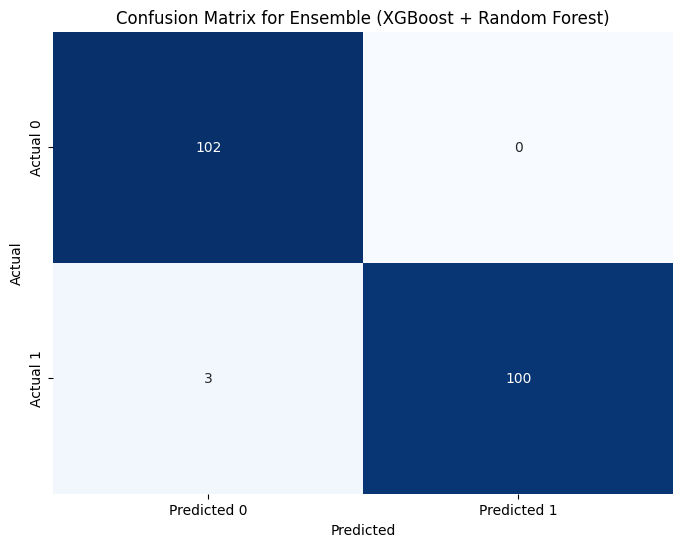

Accuracy for Ensemble: 0.9853658536585366
Precision for Ensemble: 1.0
Recall for Ensemble: 0.970873786407767
F1 Score for Ensemble: 0.9852216748768473


In [ ]:
#ensemble of XGBOOST and Random forest
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Assuming X_train, X_test, y_train, y_test are your training and testing data

# Define individual classifiers
xgb_clf = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=7, reg_lambda=0.1)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Create a Voting Classifier
voting_clf = VotingClassifier(estimators=[('xgb', xgb_clf), ('rf', rf_clf)], voting='hard')

# Fit the ensemble model
voting_clf.fit(X_train, y_train)

# Predictions on the test set
y_pred_ensemble = voting_clf.predict(X_test)

# Get the confusion matrix
conf_matrix_ensemble = confusion_matrix(y_test, y_pred_ensemble)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_ensemble, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Ensemble (XGBoost + Random Forest)')
plt.show()

# Calculate additional evaluation metrics
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
precision_ensemble = precision_score(y_test, y_pred_ensemble)
recall_ensemble = recall_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble)

# Print the evaluation metrics for the ensemble
print("Accuracy for Ensemble:", accuracy_ensemble)
print("Precision for Ensemble:", precision_ensemble)
print("Recall for Ensemble:", recall_ensemble)
print("F1 Score for Ensemble:", f1_ensemble)


Metrics for feature 'age':
Disparate Impact: nan
Statistical Parity Difference: nan
Equal Opportunity Difference: nan

Metrics for feature 'sex':
Disparate Impact: 1.0
Statistical Parity Difference: 0.0
Equal Opportunity Difference: 0.0

Metrics for feature 'cp':
Disparate Impact: 1.0000000000000009
Statistical Parity Difference: 4.440892098500626e-16
Equal Opportunity Difference: 0.0

Metrics for feature 'trestbps':
Disparate Impact: nan
Statistical Parity Difference: nan
Equal Opportunity Difference: nan

Metrics for feature 'chol':
Disparate Impact: nan
Statistical Parity Difference: nan
Equal Opportunity Difference: nan

Metrics for feature 'fbs':
Disparate Impact: 1.0000000000000004
Statistical Parity Difference: 2.220446049250313e-16
Equal Opportunity Difference: 0.0

Metrics for feature 'restecg':
Disparate Impact: 1.0000000000000002
Statistical Parity Difference: 1.1102230246251565e-16
Equal Opportunity Difference: 0.0

Metrics for feature 'thalach':
Disparate Impact: nan
Stat

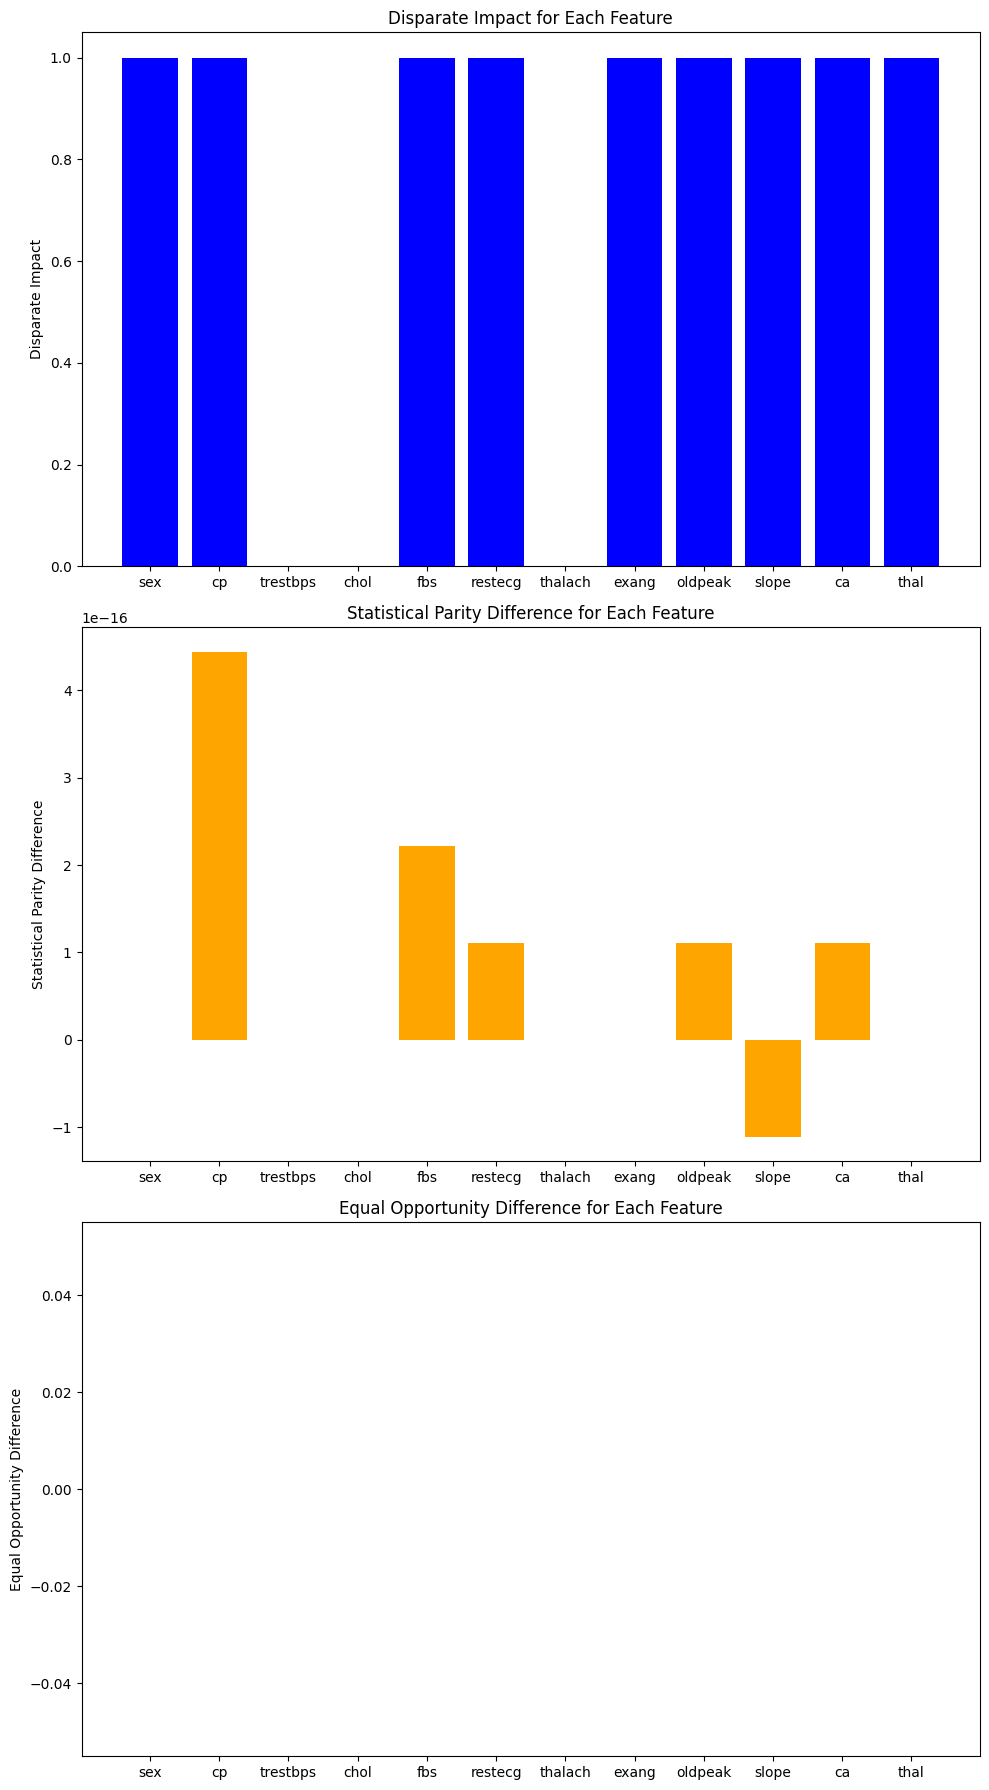

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from aif360.datasets import StandardDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing

# Load your dataset (replace AdultDataset with your dataset class)
# df = pd.read_csv('heart.csv')

# Assuming 'target' is your target column
target_column = 'target'

# Features to check for bias (replace with your actual feature columns)
feature_columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                   'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# Initialize lists to store fairness metrics
disparate_impact_values = []
statistical_parity_difference_values = []
equal_opportunity_difference_values = []

# Detect bias for each feature
for protected_attribute in feature_columns:
    # Create a BinaryLabelDataset
    dataset = StandardDataset(df, label_name=target_column, favorable_classes=[1],
                              protected_attribute_names=[protected_attribute], privileged_classes=[[1]])

    # Apply reweighing preprocessing algorithm
    preprocessor = Reweighing(unprivileged_groups=[{protected_attribute: 0}],
                              privileged_groups=[{protected_attribute: 1}])
    preprocessed_dataset = preprocessor.fit_transform(dataset)

    # Calculate fairness metrics using BinaryLabelDatasetMetric
    metric = BinaryLabelDatasetMetric(preprocessed_dataset, unprivileged_groups=[{protected_attribute: 0}],
                                      privileged_groups=[{protected_attribute: 1}])

    classified_metric = ClassificationMetric(preprocessed_dataset,
                                          preprocessed_dataset,
                                          unprivileged_groups=[{protected_attribute: 0}],
                                          privileged_groups=[{protected_attribute: 1}])

    # Append fairness metric values to lists
    disparate_impact_values.append(metric.disparate_impact())
    statistical_parity_difference_values.append(metric.statistical_parity_difference())
    equal_opportunity_difference_values.append(classified_metric.equal_opportunity_difference())

    # Display fairness metrics for each feature
    print(f"\nMetrics for feature '{protected_attribute}':")
    print("Disparate Impact:", metric.disparate_impact())
    print("Statistical Parity Difference:", metric.statistical_parity_difference())
    print("Equal Opportunity Difference:", classified_metric.equal_opportunity_difference())

# Visualize fairness metrics separately
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))

# Plot Disparate Impact
ax1.bar(feature_columns, disparate_impact_values, color='blue')
ax1.set_ylabel('Disparate Impact')
ax1.set_title('Disparate Impact for Each Feature')

# Plot Statistical Parity Difference
ax2.bar(feature_columns, statistical_parity_difference_values, color='orange')
ax2.set_ylabel('Statistical Parity Difference')
ax2.set_title('Statistical Parity Difference for Each Feature')

# Plot Equal Opportunity Difference
ax3.bar(feature_columns, equal_opportunity_difference_values, color='green')
ax3.set_ylabel('Equal Opportunity Difference')
ax3.set_title('Equal Opportunity Difference for Each Feature')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

# Assuming you have a dataset in a Pandas DataFrame
# Replace 'your_dataset.csv' with your actual dataset file
# dataset = pd.read_csv('heart.csv')

# Assuming you have columns like 'feature1', 'feature2', ..., 'feature13', 'target', 'protected_attribute'
# Replace these with your actual column names
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                   'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
target_column = 'target'
protected_attribute = 'sex'

# Convert the Pandas DataFrame to a BinaryLabelDataset
binary_dataset = BinaryLabelDataset(
    favorable_label=1,
    unfavorable_label=0,
    df=df,
    label_names=[target_column],
    protected_attribute_names=[protected_attribute]
)

# Apply reweighing preprocessing algorithm
preprocessor = Reweighing(unprivileged_groups=[{protected_attribute: 0}],
                           privileged_groups=[{protected_attribute: 1}])
preprocessed_dataset = preprocessor.fit_transform(binary_dataset)

# Convert the preprocessed dataset back to a Pandas DataFrame
preprocessed_df = preprocessed_dataset.convert_to_dataframe()

# Now 'preprocessed_df' contains the preprocessed dataset


Selecting features and target

In [ ]:
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach','exang', 'oldpeak', 'slope', 'ca', 'thal']
target = 'target'

Train and test split

In [ ]:
#splitting
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Trying different models**

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb

# Assuming X_train, X_test, y_train, y_test are your training and testing data

# Define classifiers
classifiers = {
    'XGB': xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=7, reg_lambda=0.1),
    #'LGBM': lgb.LGBMClassifier(objective='binary', n_estimators=100, learning_rate=0.1, max_depth=7, reg_lambda=0.1),
    'SVC': SVC(kernel='rbf'),
    #'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GaussianNB': GaussianNB(),
    'NN': MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000)
}

# Initialize a DataFrame to store results
results_df = pd.DataFrame(columns=['Classifier', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

# Loop through classifiers
for clf_name, clf in classifiers.items():
    # Fit the classifier
    clf.fit(X_train, y_train)

    # Predictions on the test set
    y_pred = clf.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Append results to DataFrame
    results_df = results_df.append({'Classifier': clf_name,
                                    'Accuracy': accuracy,
                                    'Precision': precision,
                                    'Recall': recall,
                                    'F1 Score': f1}, ignore_index=True)

# Display the results DataFrame
print(results_df)


   Classifier  Accuracy  Precision    Recall  F1 Score
0         XGB  0.985366   1.000000  0.970874  0.985222
1         SVC  0.682927   0.661017  0.757282  0.705882
2  GaussianNB  0.800000   0.754098  0.893204  0.817778
3          NN  0.775610   0.761468  0.805825  0.783019


**XGBOOST**

In [ ]:
#XGBOOST
xgb_clf = xgb.XGBClassifier(objective='binary:logistic')
parameters = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [7],
    'reg_lambda': [0.1, 0.3]
}
xgb_clf_cv = GridSearchCV(estimator=xgb_clf, param_grid=parameters, cv=5, n_jobs=-1)
xgb_clf_cv.fit(X_train, y_train)
print("Best score: %0.3f" % xgb_clf_cv.best_score_)
print("Best parameters set:", xgb_clf_cv.best_params_)

Best score: 0.982
Best parameters set: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'reg_lambda': 0.1}


In [ ]:
#gridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming X_train, X_test, y_train, y_test are your training and testing data

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [5, 7, 9],
    'reg_lambda': [0.1, 0.5, 1]
}

# Create the XGBoost model
xgb_clf = xgb.XGBClassifier(objective='binary:logistic')

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, cv=5, n_jobs=-1)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Print the best hyperparameters
print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150, 'reg_lambda': 0.5}


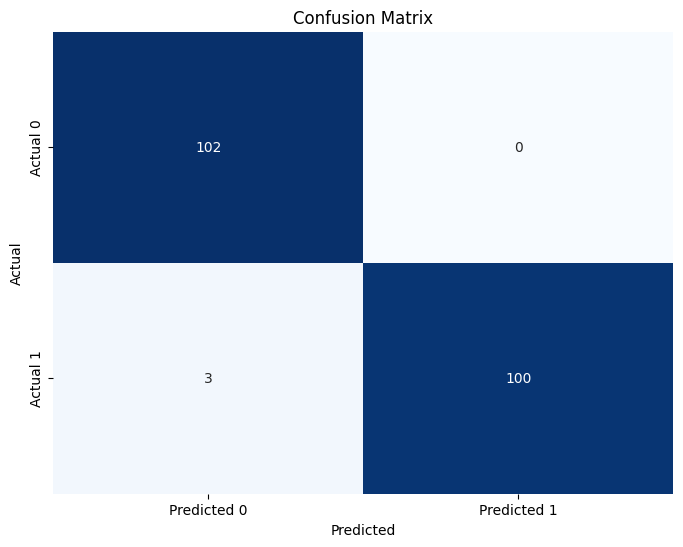

Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767
F1 Score: 0.9852216748768473


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming X_train, X_test, y_train, y_test are your training and testing data
# Assuming you have already performed the GridSearchCV as in your initial code

# Fit the XGBoost model
xgb_clf = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=7, reg_lambda=0.1)
xgb_clf.fit(X_train, y_train)

# Predictions on the test set
y_pred = xgb_clf.predict(X_test)

# Get the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Calculate additional evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


**DIR on XGB**

Ratios for each feature:
age         0.969917
sex              inf
cp          0.904952
trestbps    0.976806
chol        0.925506
fbs         1.000000
restecg     0.857143
thalach     0.983565
exang       1.466518
oldpeak     1.267029
slope       0.998747
ca          1.526984
thal        1.107210
dtype: float64


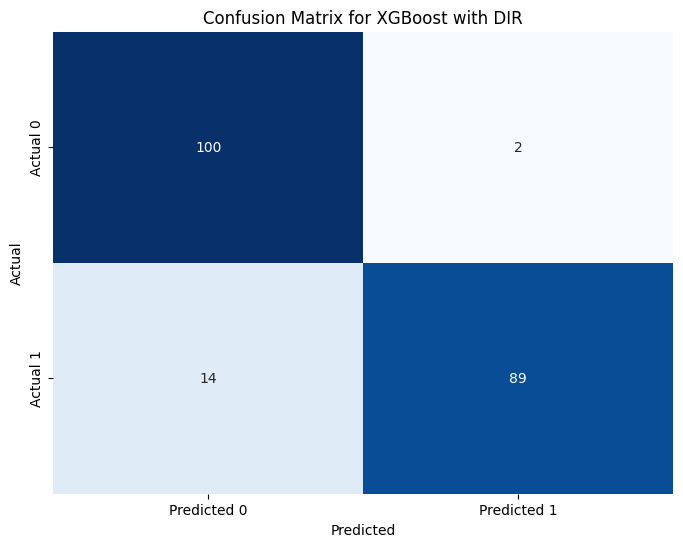


Evaluation Metrics:
Accuracy: 0.9219512195121952
Precision: 0.978021978021978
Recall: 0.8640776699029126
F1 Score: 0.9175257731958761


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have a dataset in a Pandas DataFrame
# Replace 'your_dataset.csv' with your actual dataset file
#df = pd.read_csv('your_dataset.csv')

# Assuming you have columns like 'age', 'sex', ..., 'thal', 'target', 'sex'
# Replace these with your actual column names
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
target_column = 'target'
protected_attribute = 'sex'

# Split your data into X and y
X = df[features]
y = df[target_column]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate privileged and unprivileged groups
privileged_group = X_train[X_train[protected_attribute] == 1]
unprivileged_group = X_train[X_train[protected_attribute] == 0]

# Calculate the ratio of privileged to unprivileged group samples for each feature
ratios = privileged_group.mean() / unprivileged_group.mean()

# Apply the ratio adjustment to the unprivileged group
X_train_adjusted = X_train.copy()
for feature in features:
    X_train_adjusted.loc[X_train[protected_attribute] == 0, feature] *= ratios[feature]

# Print the calculated ratios
print("Ratios for each feature:")
print(ratios)

# Train XGBoost model on the adjusted data
xgb_clf = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=7, reg_lambda=0.1)
xgb_clf.fit(X_train_adjusted, y_train)

# Predictions on the original test set
y_pred = xgb_clf.predict(X_test)

# Get the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost with DIR')
plt.show()

# Calculate additional evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the evaluation metrics
print("\nEvaluation Metrics:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


**Adversarial Debiasing**

In [ ]:
import pandas as pd
import tensorflow as tf
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.inprocessing import AdversarialDebiasing
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score

# Disable eager execution
tf.compat.v1.disable_eager_execution()

# Reset the default TensorFlow graph
tf.compat.v1.reset_default_graph()

# Assuming you have a dataset in a Pandas DataFrame
# Replace 'heart.csv' with your actual dataset file
dataset = pd.read_csv('heart.csv')

# Assuming you have columns like 'age', 'sex', ..., 'thal', 'target', 'sex'
# Replace these with your actual column names
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
target_column = 'target'
protected_attribute = 'sex'

# Convert the Pandas DataFrame to a BinaryLabelDataset
binary_dataset = BinaryLabelDataset(
    favorable_label=1,
    unfavorable_label=0,
    df=dataset,
    label_names=[target_column],
    protected_attribute_names=[protected_attribute]
)

# Split the dataset into train and test sets
train_df, test_df = train_test_split(dataset, test_size=0.2, random_state=42)

# Train XGBoost
xgb_model = XGBClassifier()
xgb_model.fit(train_df[features], train_df[target_column])
xgb_predictions = xgb_model.predict(test_df[features])

# Evaluate XGBoost
xgb_accuracy = accuracy_score(test_df[target_column], xgb_predictions)
xgb_f1_score = f1_score(test_df[target_column], xgb_predictions)
xgb_precision = precision_score(test_df[target_column], xgb_predictions)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost F1 Score:", xgb_f1_score)
print("XGBoost Precision:", xgb_precision)

# Train Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(train_df[features], train_df[target_column])
rf_predictions = rf_model.predict(test_df[features])

# Evaluate Random Forest
rf_accuracy = accuracy_score(test_df[target_column], rf_predictions)
rf_f1_score = f1_score(test_df[target_column], rf_predictions)
rf_precision = precision_score(test_df[target_column], rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest F1 Score:", rf_f1_score)
print("Random Forest Precision:", rf_precision)

# Create a TensorFlow session
sess = tf.compat.v1.Session()

# Apply AdversarialDebiasing in-processing algorithm
with tf.compat.v1.variable_scope('debiased_classifier', reuse=tf.compat.v1.AUTO_REUSE):
    adversarial_debiasing = AdversarialDebiasing(unprivileged_groups=[{protected_attribute: 0}],
                                                 privileged_groups=[{protected_attribute: 1}],
                                                 scope_name='debiased_classifier',
                                                 debias=True, sess=sess)

adversarial_debiasing.fit(binary_dataset)

# Get predictions on the original dataset
predictions = adversarial_debiasing.predict(binary_dataset)

# Create a copy of the original dataset with predicted labels
debiasing_dataset = binary_dataset.copy(deepcopy=True)
debiasing_dataset.labels = predictions.labels

# Evaluate the debiased dataset for fairness metrics
metric = BinaryLabelDatasetMetric(debiasing_dataset,
                                  unprivileged_groups=[{protected_attribute: 0}],
                                  privileged_groups=[{protected_attribute: 1}])

classified_metric = ClassificationMetric(debiasing_dataset,
                                         debiasing_dataset,
                                         unprivileged_groups=[{protected_attribute: 0}],
                                         privileged_groups=[{protected_attribute: 1}])

# Display fairness metrics for Adversarial Debiasing
print("Adversarial Debiasing - Disparate Impact:", metric.disparate_impact())
print("Adversarial Debiasing - Statistical Parity Difference:", metric.statistical_parity_difference())
print("Adversarial Debiasing - Equal Opportunity Difference:", classified_metric.equal_opportunity_difference())


XGBoost Accuracy: 0.9853658536585366
XGBoost F1 Score: 0.9852216748768473
XGBoost Precision: 1.0
Random Forest Accuracy: 0.9853658536585366
Random Forest F1 Score: 0.9852216748768473
Random Forest Precision: 1.0
epoch 0; iter: 0; batch classifier loss: 8.652096; batch adversarial loss: 0.653388
epoch 1; iter: 0; batch classifier loss: 4.164562; batch adversarial loss: 0.641251
epoch 2; iter: 0; batch classifier loss: 4.852169; batch adversarial loss: 0.660753
epoch 3; iter: 0; batch classifier loss: 4.301498; batch adversarial loss: 0.649416
epoch 4; iter: 0; batch classifier loss: 3.313960; batch adversarial loss: 0.672142
epoch 5; iter: 0; batch classifier loss: 3.774631; batch adversarial loss: 0.646701
epoch 6; iter: 0; batch classifier loss: 2.968528; batch adversarial loss: 0.642609
epoch 7; iter: 0; batch classifier loss: 2.617058; batch adversarial loss: 0.651307
epoch 8; iter: 0; batch classifier loss: 2.256463; batch adversarial loss: 0.618711
epoch 9; iter: 0; batch classifi

**XGBOOST with User Input and prediction**

In [ ]:
import xgboost as xgb
import pandas as pd

# Assuming 'features' and 'target' are defined
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach','exang', 'oldpeak', 'slope', 'ca', 'thal']
target = 'target'

# Assuming 'X_train' and 'y_train' are your training data
# Assuming you have already performed the GridSearchCV as in your initial code
# Fit the XGBoost model
xgb_clf = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=7, reg_lambda=0.1)
xgb_clf.fit(X_train[features], y_train)

# Take user input for each feature
user_input = {}
for feature in features:
    value = input(f"Enter the value for {feature}: ")
    user_input[feature] = float(value) if feature != 'sex' else int(value)  # Convert to appropriate data type

# Convert user input to a DataFrame
user_df = pd.DataFrame([user_input], columns=features)

# Make prediction
user_pred = xgb_clf.predict(user_df)

# Print the prediction
if user_pred[0] == 0:
    print("The user is predicted to not have heart disease.")
else:
    print("The user is predicted to have heart disease.")


Enter the value for age: 20
Enter the value for sex: 1
Enter the value for cp: 0
Enter the value for trestbps: 125
Enter the value for chol: 174
Enter the value for fbs: 1
Enter the value for restecg: 0
Enter the value for thalach: 125
Enter the value for exang: 1
Enter the value for oldpeak: 3.1
Enter the value for slope: 2
Enter the value for ca: 2
Enter the value for thal: 3
The user is predicted to not have heart disease.


**Ensemble of XGBOOST and Random forest**

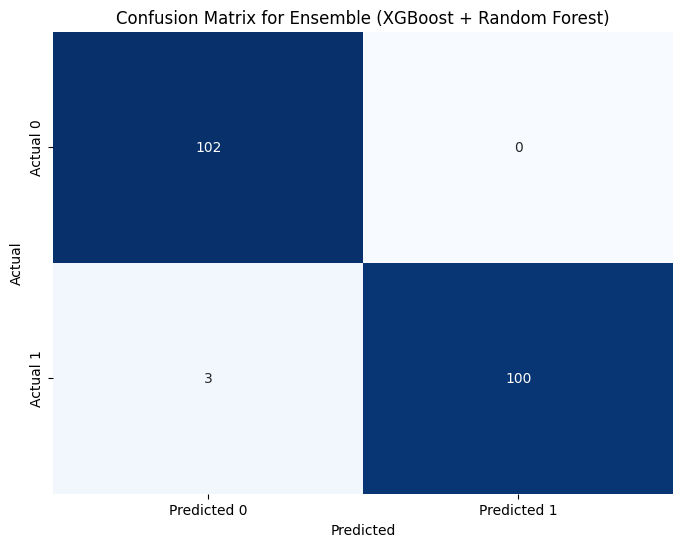

Accuracy for Ensemble: 0.9853658536585366
Precision for Ensemble: 1.0
Recall for Ensemble: 0.970873786407767
F1 Score for Ensemble: 0.9852216748768473


In [ ]:
#ensemble of XGBOOST and Random forest
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Assuming X_train, X_test, y_train, y_test are your training and testing data

# Define individual classifiers
xgb_clf = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=7, reg_lambda=0.1)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Create a Voting Classifier
voting_clf = VotingClassifier(estimators=[('xgb', xgb_clf), ('rf', rf_clf)], voting='hard')

# Fit the ensemble model
voting_clf.fit(X_train, y_train)

# Predictions on the test set
y_pred_ensemble = voting_clf.predict(X_test)

# Get the confusion matrix
conf_matrix_ensemble = confusion_matrix(y_test, y_pred_ensemble)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_ensemble, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Ensemble (XGBoost + Random Forest)')
plt.show()

# Calculate additional evaluation metrics
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
precision_ensemble = precision_score(y_test, y_pred_ensemble)
recall_ensemble = recall_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble)

# Print the evaluation metrics for the ensemble
print("Accuracy for Ensemble:", accuracy_ensemble)
print("Precision for Ensemble:", precision_ensemble)
print("Recall for Ensemble:", recall_ensemble)
print("F1 Score for Ensemble:", f1_ensemble)


**LIME**

In [ ]:
import lime
from lime import lime_tabular

explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['No Heart Disease', 'Yes Heart Disease'],
    mode='classification'
)

In [ ]:
exp = explainer.explain_instance(
    data_row=X_test.iloc[1],
    predict_fn=model.predict_proba
)

exp.show_in_notebook(show_table=True)

**SHAP**

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

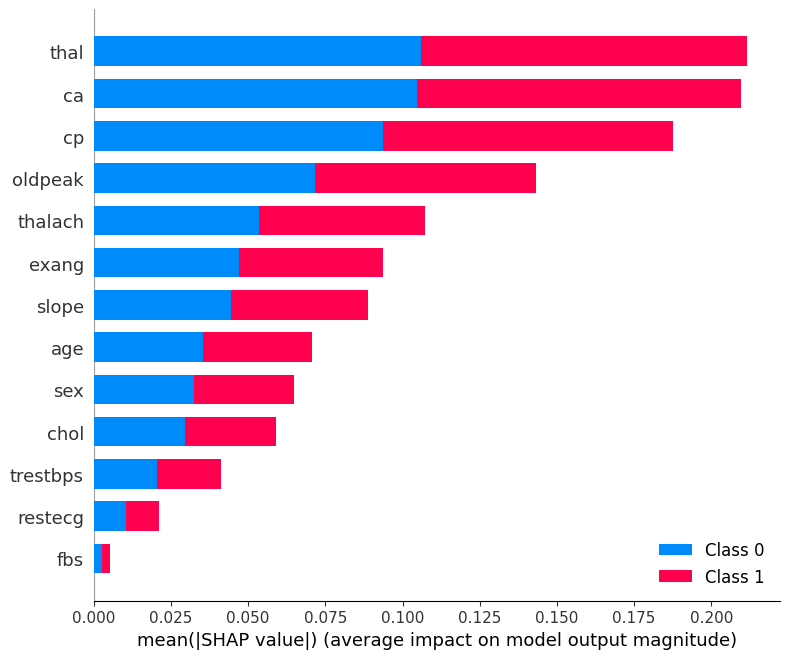

In [ ]:
shap.summary_plot(shap_values, X)

**Ensemble model with Advarsarial Debiasing**


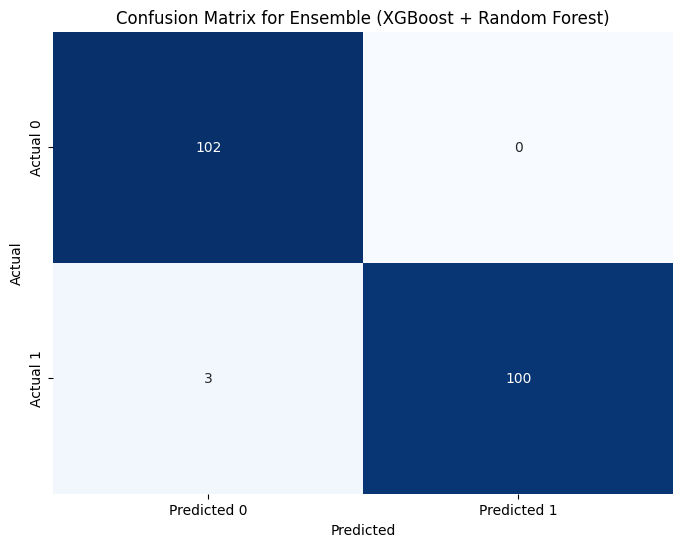

Accuracy for Ensemble: 0.9853658536585366
Precision for Ensemble: 1.0
Recall for Ensemble: 0.970873786407767
F1 Score for Ensemble: 0.9852216748768473
epoch 0; iter: 0; batch classifier loss: 27.814762; batch adversarial loss: 0.693147
epoch 1; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 2; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 3; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 4; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 5; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 6; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 7; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 8; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 9; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 10; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 11; iter: 0; batc

In [ ]:
import pandas as pd
import tensorflow as tf
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.inprocessing import AdversarialDebiasing
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Disable eager execution
tf.compat.v1.disable_eager_execution()

# Reset the default TensorFlow graph
tf.compat.v1.reset_default_graph()

# Assuming you have a dataset in a Pandas DataFrame
# Replace 'heart.csv' with your actual dataset file
dataset = pd.read_csv('heart.csv')

# Assuming you have columns like 'age', 'sex', ..., 'thal', 'target', 'sex'
# Replace these with your actual column names
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
target_column = 'target'
protected_attribute = 'sex'

# Convert the Pandas DataFrame to a BinaryLabelDataset
binary_dataset = BinaryLabelDataset(
    favorable_label=1,
    unfavorable_label=0,
    df=dataset,
    label_names=[target_column],
    protected_attribute_names=[protected_attribute]
)

# Split your data into X and y
X = dataset[features]
y = dataset[target_column]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define individual classifiers
xgb_clf = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=7, reg_lambda=0.1)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Create a Voting Classifier
voting_clf = VotingClassifier(estimators=[('xgb', xgb_clf), ('rf', rf_clf)], voting='hard')

# Fit the ensemble model
voting_clf.fit(X_train, y_train)

# Predictions on the test set
y_pred_ensemble = voting_clf.predict(X_test)

# Get the confusion matrix
conf_matrix_ensemble = confusion_matrix(y_test, y_pred_ensemble)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_ensemble, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Ensemble (XGBoost + Random Forest)')
plt.show()

# Calculate additional evaluation metrics
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
precision_ensemble = precision_score(y_test, y_pred_ensemble)
recall_ensemble = recall_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble)

# Print the evaluation metrics for the ensemble
print("Accuracy for Ensemble:", accuracy_ensemble)
print("Precision for Ensemble:", precision_ensemble)
print("Recall for Ensemble:", recall_ensemble)
print("F1 Score for Ensemble:", f1_ensemble)

# Apply AdversarialDebiasing in-processing algorithm
with tf.compat.v1.variable_scope('debiased_classifier', reuse=tf.compat.v1.AUTO_REUSE):
    adversarial_debiasing = AdversarialDebiasing(unprivileged_groups=[{protected_attribute: 0}],
                                                 privileged_groups=[{protected_attribute: 1}],
                                                 scope_name='debiased_classifier',
                                                 debias=True, sess=tf.compat.v1.Session())

adversarial_debiasing.fit(binary_dataset)

# Get predictions on the original dataset
predictions = adversarial_debiasing.predict(binary_dataset)

# Create a copy of the original dataset with predicted labels
debiasing_dataset = binary_dataset.copy(deepcopy=True)
debiasing_dataset.labels = predictions.labels

# Evaluate the debiased dataset for fairness metrics
metric = BinaryLabelDatasetMetric(debiasing_dataset,
                                  unprivileged_groups=[{protected_attribute: 0}],
                                  privileged_groups=[{protected_attribute: 1}])

classified_metric = ClassificationMetric(debiasing_dataset,
                                          debiasing_dataset,
                                          unprivileged_groups=[{protected_attribute: 0}],
                                          privileged_groups=[{protected_attribute: 1}])

# Display fairness metrics
print("Disparate Impact:", metric.disparate_impact())
print("Statistical Parity Difference:", metric.statistical_parity_difference())
print("Equal Opportunity Difference:", classified_metric.equal_opportunity_difference())


**Esemble model with user i/p and prediction**

In [ ]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Assuming 'features' and 'target' are defined
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
target = 'target'

# Assuming 'X_train' and 'y_train' are your training data
# Assuming you have already performed the GridSearchCV as in your initial code

# Fit XGBoost model
xgb_clf = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=7, reg_lambda=0.1)
xgb_clf.fit(X_train[features], y_train)

# Fit Random Forest model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train[features], y_train)

# Take user input for each feature
user_input = {}
for feature in features:
    value = input(f"Enter the value for {feature}: ")
    user_input[feature] = float(value) if feature != 'sex' else int(value)  # Convert to appropriate data type

# Convert user input to a DataFrame
user_df = pd.DataFrame([user_input], columns=features)

# Make predictions
xgb_pred = xgb_clf.predict(user_df)
rf_pred = rf_clf.predict(user_df)

# Combine predictions (for simplicity, using majority voting)
ensemble_pred = 1 if (xgb_pred.sum() + rf_pred.sum()) > 1 else 0

# Print the ensemble prediction
if ensemble_pred == 0:
    print("The user is predicted to not have heart disease.")
else:
    print("The user is predicted to have heart disease.")


Enter the value for age: 20
Enter the value for sex: 1
Enter the value for cp: 0
Enter the value for trestbps: 125
Enter the value for chol: 174
Enter the value for fbs: 30
Enter the value for restecg: 23
Enter the value for thalach: 200
Enter the value for exang: 1
Enter the value for oldpeak: 0
Enter the value for slope: 3
Enter the value for ca: 2
Enter the value for thal: 2
The user is predicted to not have heart disease.
